In [87]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


from importlib import reload
import kan
reload(kan)

from kan import KAN

# One input-one output function approximation task

## Regression sanity test

This test checks whether the tanh-basis KAN can learn a simple nonlinear mapping before moving to more complex tasks.

The model is trained on a 2D regression problem with positive inputs $x_1, x_2 \in (0,1]$, using the target function

$$
y = \sin(3x_1x_2) + 0.2x_1 + 0.1x_2^2
$$

This is a useful sanity check because it is small, easy to visualize, and still contains a nonlinear interaction term.  
I compare a shallow KAN and a KAN with one hidden layer, and I inspect the hidden activations to understand why deeper versions may fail or succeed.

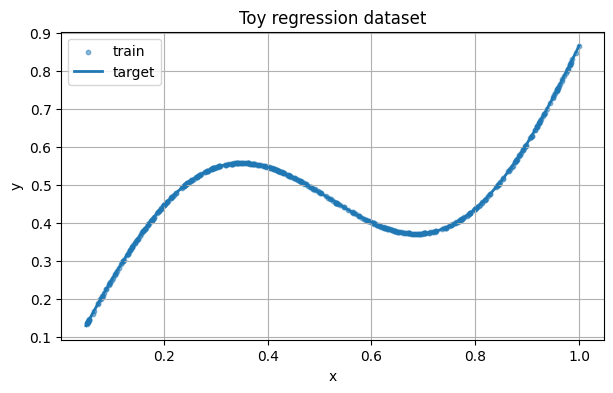

In [88]:
torch.manual_seed(42)

# Positive inputs in (0, 1]
n_train = 512
n_test = 200

x_train = 0.05 + 0.95 * torch.rand(n_train, 1)
x_test = torch.linspace(0.05, 1.0, n_test).unsqueeze(1)

# A smooth nonlinear target
def target_fn(x):
    return 0.8 * x + 0.3 * torch.sin(6.0 * x) + 0.15 * x**2

y_train = target_fn(x_train)
y_test = target_fn(x_test)

plt.figure(figsize=(7, 4))
plt.scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.5, label="train")
plt.plot(x_test.numpy(), y_test.numpy(), linewidth=2, label="target")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy regression dataset")
plt.legend()
plt.grid(True)
plt.show()

In [89]:
model = KAN(
    in_count=1,
    out_count=1,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
)

print(model)

KAN(
  (layers): ModuleList(
    (0): TanhBasisActivationLayer()
  )
)


In [90]:
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

num_epochs = 2000
losses = []

for epoch in range(num_epochs):
    model.train()

    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss.item():.6f}")

Epoch    0 | Loss = 0.241149
Epoch  200 | Loss = 0.000076
Epoch  400 | Loss = 0.000054
Epoch  600 | Loss = 0.000049
Epoch  800 | Loss = 0.000048
Epoch 1000 | Loss = 0.000048
Epoch 1200 | Loss = 0.000048
Epoch 1400 | Loss = 0.000048
Epoch 1600 | Loss = 0.000048
Epoch 1800 | Loss = 0.000048


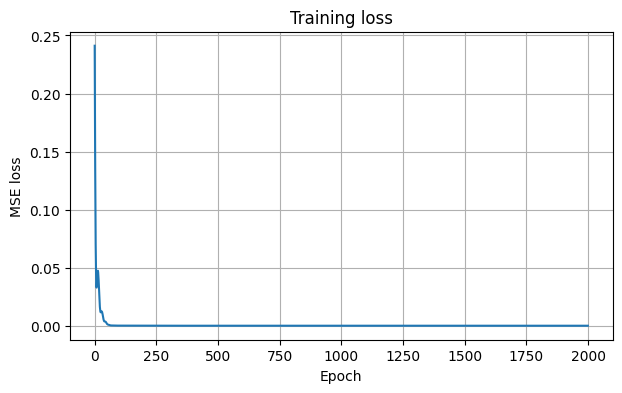

In [91]:
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.grid(True)
plt.show()

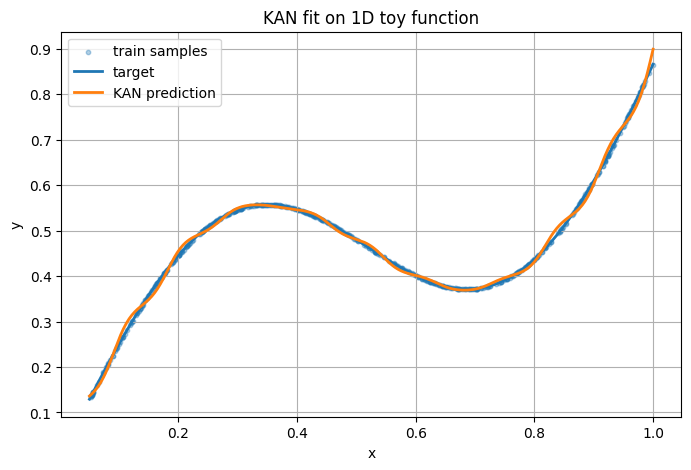

In [92]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)

plt.figure(figsize=(8, 5))
plt.scatter(x_train.numpy(), y_train.numpy(), s=10, alpha=0.35, label="train samples")
plt.plot(x_test.numpy(), y_test.numpy(), linewidth=2, label="target")
plt.plot(x_test.numpy(), y_pred_test.numpy(), linewidth=2, label="KAN prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("KAN fit on 1D toy function")
plt.legend()
plt.grid(True)
plt.show()

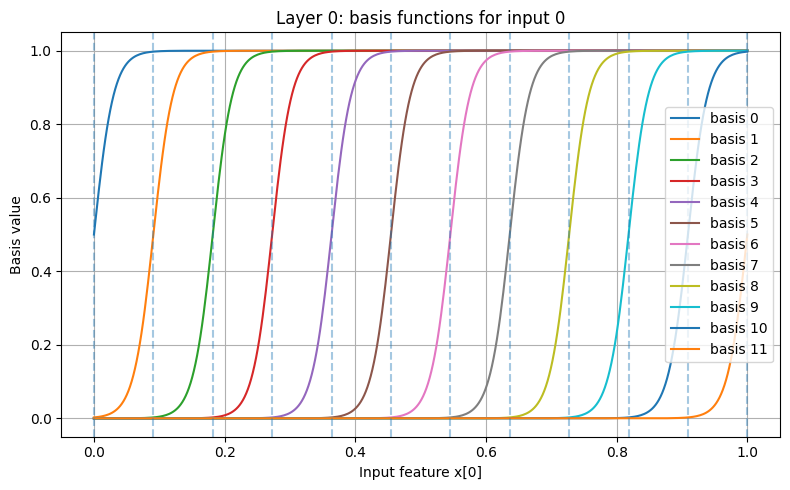

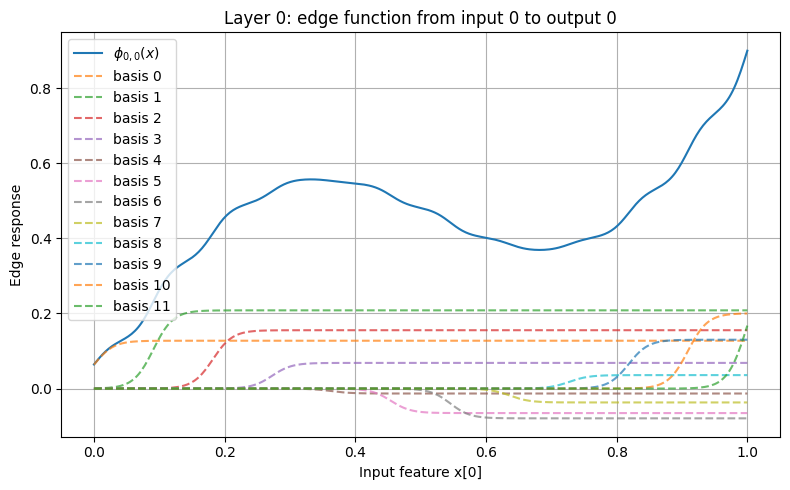

Layer 0 coefficient tensor shape: (1, 1, 12)
  min  = -0.079107
  max  = 0.335364
  mean = 0.088955
  std  = 0.126640


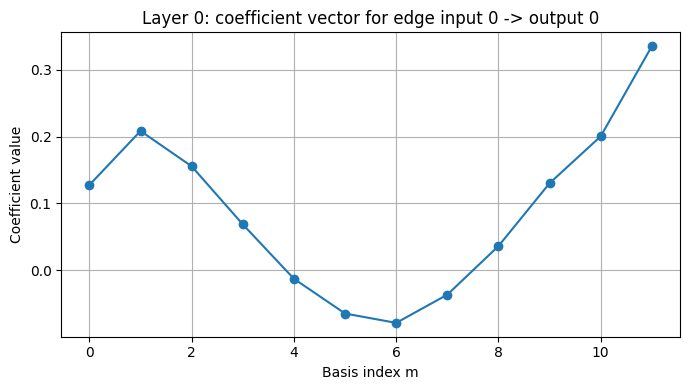

In [93]:
model.plot_basis_functions(
    layer_idx=0,
    in_idx=0,
    x_range=(0.0, 1.0),
)

model.plot_edge_function(
    layer_idx=0,
    out_idx=0,
    in_idx=0,
    x_range=(0.0, 1.0),
    show_basis=True,
)

model.print_coeff_stats(layer_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0)

## Multi-input, multi-output regression test

This test evaluates the tanh-basis KAN on a simple 2D regression task with two outputs.  
The inputs satisfy $x_1, x_2 \in (0,1]$, and the target functions are

$$
y_1 = \sin(4x_1) + 0.5x_2^2
$$

$$
y_2 = 0.3x_1^2 + \cos(3x_2)
$$

These targets are nonlinear but still additive across input coordinates, which matches the structure of a one-layer KAN:
$$
y_j = \sum_i \varphi_{ij}(x_i)
$$

In [94]:
torch.manual_seed(42)

n_train = 1000
n_test = 300

x_train = 0.05 + 0.95 * torch.rand(n_train, 2)
x_test = 0.05 + 0.95 * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    y1 = torch.sin(4.0 * x1) + 0.5 * x2**2
    y2 = 0.3 * x1**2 + torch.cos(3.0 * x2)

    return torch.cat([y1, y2], dim=1)

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [95]:
model = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
)

optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

In [96]:
num_epochs = 2500
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 250 == 0:
        print(f"Epoch {epoch:4d} | train loss = {loss.item():.6f} | test loss = {test_loss.item():.6f}")

Epoch    0 | train loss = 0.540781 | test loss = 0.453528
Epoch  250 | train loss = 0.000342 | test loss = 0.000337
Epoch  500 | train loss = 0.000204 | test loss = 0.000216
Epoch  750 | train loss = 0.000188 | test loss = 0.000199
Epoch 1000 | train loss = 0.000185 | test loss = 0.000194
Epoch 1250 | train loss = 0.000184 | test loss = 0.000192
Epoch 1500 | train loss = 0.000184 | test loss = 0.000192
Epoch 1750 | train loss = 0.000184 | test loss = 0.000192
Epoch 2000 | train loss = 0.000184 | test loss = 0.000192
Epoch 2250 | train loss = 0.000184 | test loss = 0.000192


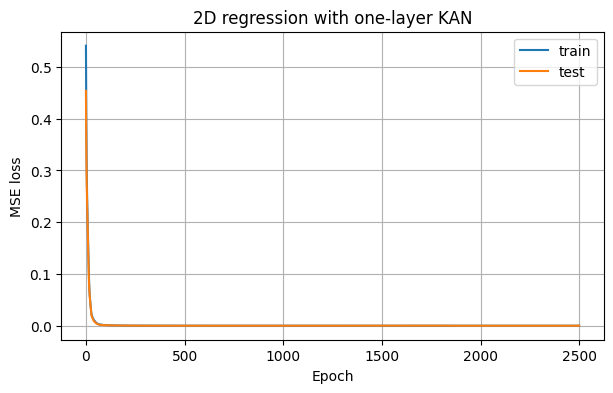

In [97]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("2D regression with one-layer KAN")
plt.legend()
plt.grid(True)
plt.show()

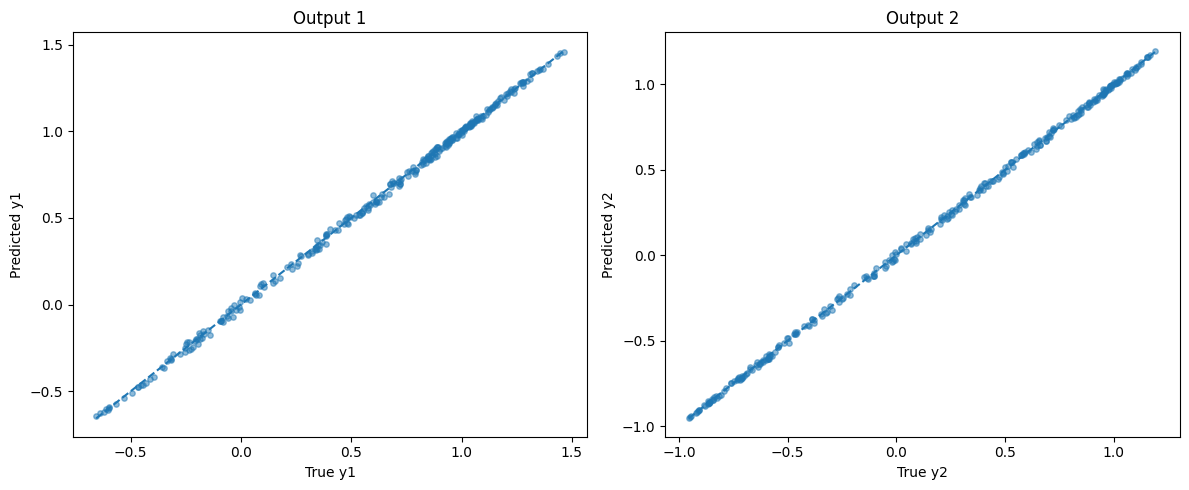

In [98]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j in range(2):
    axes[j].scatter(y_test[:, j].numpy(), y_pred_test[:, j].numpy(), alpha=0.5, s=15)
    minv = min(y_test[:, j].min().item(), y_pred_test[:, j].min().item())
    maxv = max(y_test[:, j].max().item(), y_pred_test[:, j].max().item())
    axes[j].plot([minv, maxv], [minv, maxv], linestyle="--")
    axes[j].set_xlabel(f"True y{j+1}")
    axes[j].set_ylabel(f"Predicted y{j+1}")
    axes[j].set_title(f"Output {j+1}")

plt.tight_layout()
plt.show()

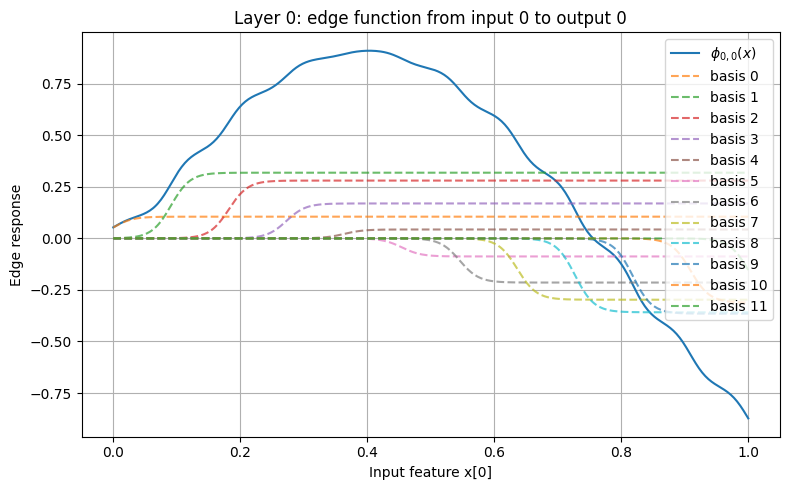

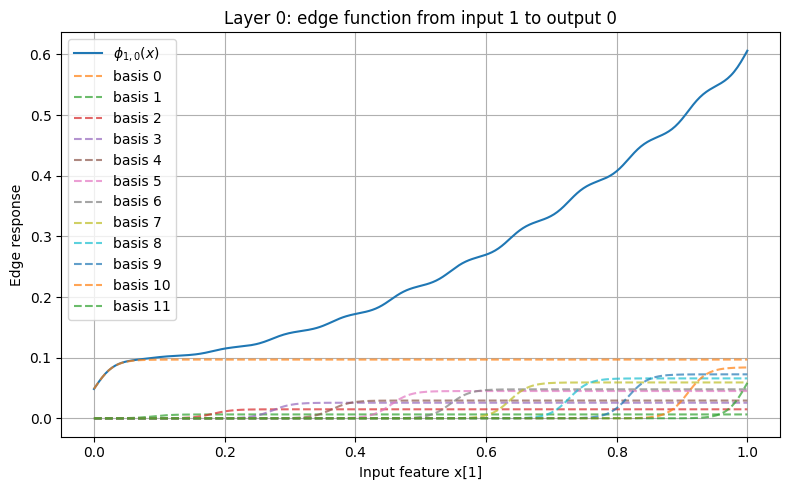

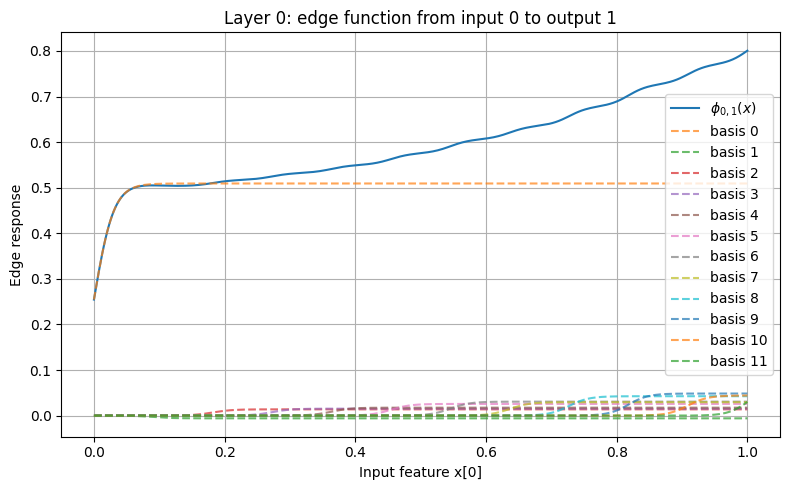

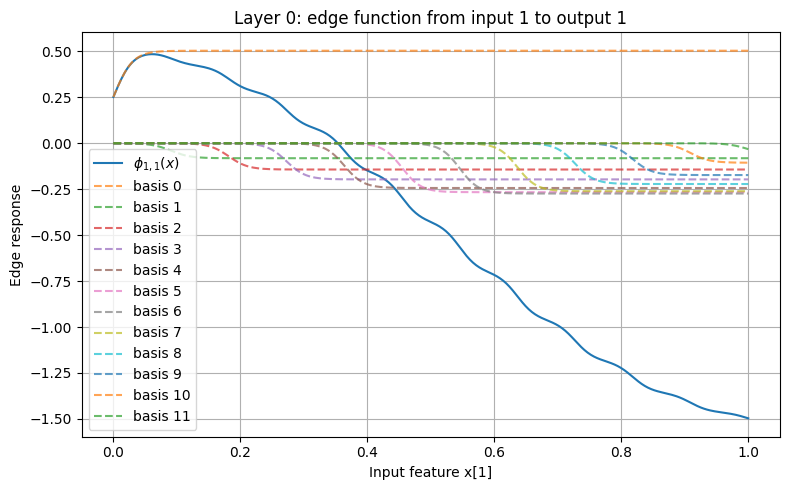

In [99]:
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 1.0), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(0.0, 1.0), show_basis=True)

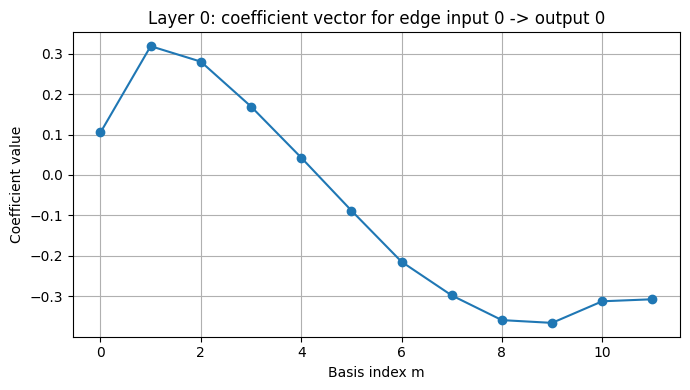

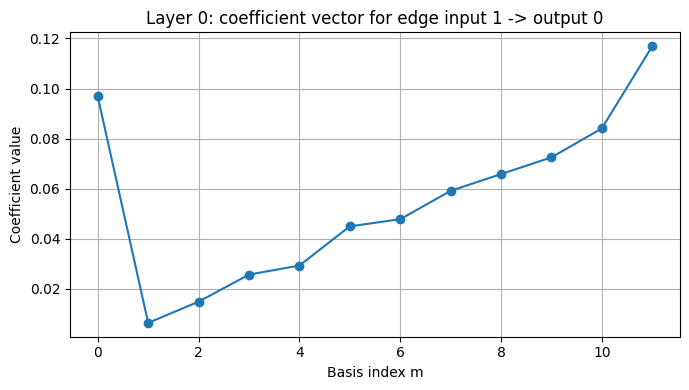

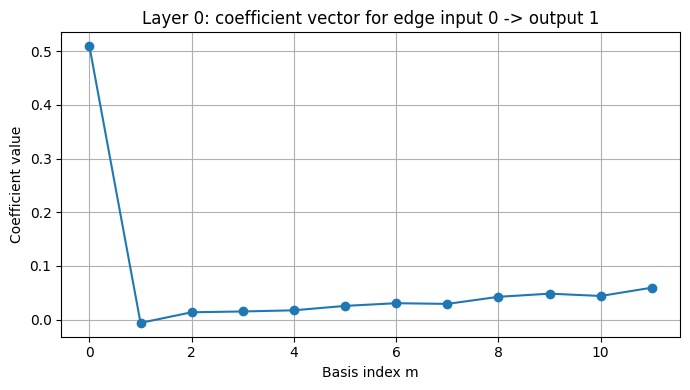

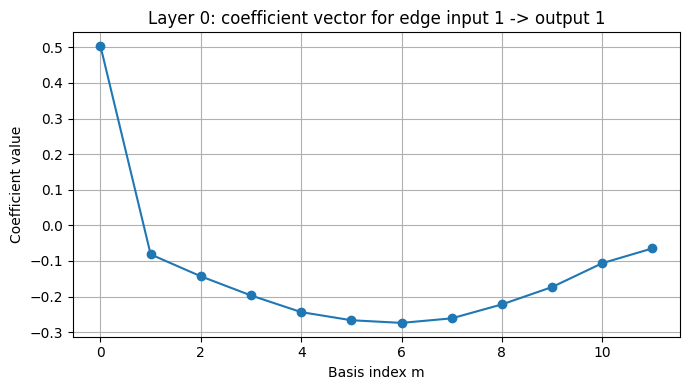

In [100]:
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=1)

## Interaction regression test

This test evaluates the tanh-basis KAN on a harder 2D regression problem with positive inputs $x_1, x_2 \in (0,1]$, using the target function

$$
y = \sin(3x_1x_2) + 0.2x_1 + 0.1x_2^2
$$

Unlike the previous additive case, this function contains an interaction term $x_1x_2$, so it is not purely separable into a sum of one-dimensional functions.  
This makes it a useful test for comparing a shallow KAN with a KAN that includes one hidden layer.

The goal is to check whether the deeper model can better capture input interactions, and to inspect the hidden activations to understand how multi-layer behavior changes.

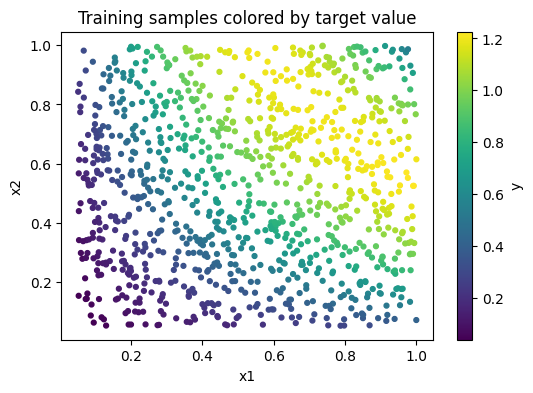

In [101]:
torch.manual_seed(42)

n_train = 1000
n_test = 300

x_train = 0.05 + 0.95 * torch.rand(n_train, 2)
x_test = 0.05 + 0.95 * torch.rand(n_test, 2)

def target_fn_interaction(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]
    y = torch.sin(3.0 * x1 * x2) + 0.2 * x1 + 0.1 * x2**2
    return y

y_train = target_fn_interaction(x_train)
y_test = target_fn_interaction(x_test)

plt.figure(figsize=(6, 4))
plt.scatter(x_train[:, 0].numpy(), x_train[:, 1].numpy(), c=y_train[:, 0].numpy(), s=12)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Training samples colored by target value")
plt.colorbar(label="y")
plt.show()

In [102]:
def train_regression_model(
    model,
    x_train,
    y_train,
    x_test,
    y_test,
    lr=1e-2,
    num_epochs=2500,
    print_every=250,
):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        y_pred = model(x_train)
        train_loss = loss_fn(y_pred, y_train)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            y_test_pred = model(x_test)
            test_loss = loss_fn(y_test_pred, y_test)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train loss = {train_loss.item():.6f} | "
                f"test loss = {test_loss.item():.6f}"
            )

    return train_losses, test_losses

In [103]:
def plot_predictions_vs_truth(model, x_test, y_test, title="Prediction vs truth"):
    model.eval()
    with torch.no_grad():
        y_pred = model(x_test)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test[:, 0].numpy(), y_pred[:, 0].numpy(), alpha=0.5, s=18)

    minv = min(y_test.min().item(), y_pred.min().item())
    maxv = max(y_test.max().item(), y_pred.max().item())
    plt.plot([minv, maxv], [minv, maxv], linestyle="--")

    plt.xlabel("True y")
    plt.ylabel("Predicted y")
    plt.title(title)
    plt.grid(True)
    plt.show()

In [104]:
def plot_loss_curves(train_losses, test_losses, title="Loss curves"):
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="train")
    plt.plot(test_losses, label="test")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [105]:
model_shallow = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=0.0,
    x_max=1.0,
    gamma_scale=3.0,
    debug=False,
)

train_losses_shallow, test_losses_shallow = train_regression_model(
    model=model_shallow,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    lr=1e-2,
    num_epochs=2500,
    print_every=250,
)

Epoch    0 | train loss = 0.611043 | test loss = 0.448464
Epoch  250 | train loss = 0.013708 | test loss = 0.014768
Epoch  500 | train loss = 0.012966 | test loss = 0.014356
Epoch  750 | train loss = 0.012796 | test loss = 0.014301
Epoch 1000 | train loss = 0.012729 | test loss = 0.014312
Epoch 1250 | train loss = 0.012703 | test loss = 0.014337
Epoch 1500 | train loss = 0.012694 | test loss = 0.014358
Epoch 1750 | train loss = 0.012691 | test loss = 0.014371
Epoch 2000 | train loss = 0.012691 | test loss = 0.014378
Epoch 2250 | train loss = 0.012691 | test loss = 0.014381


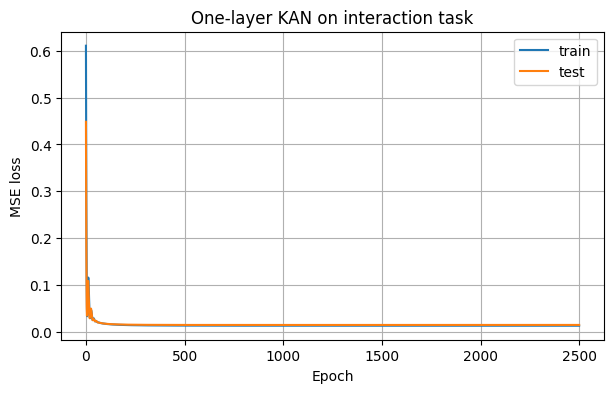

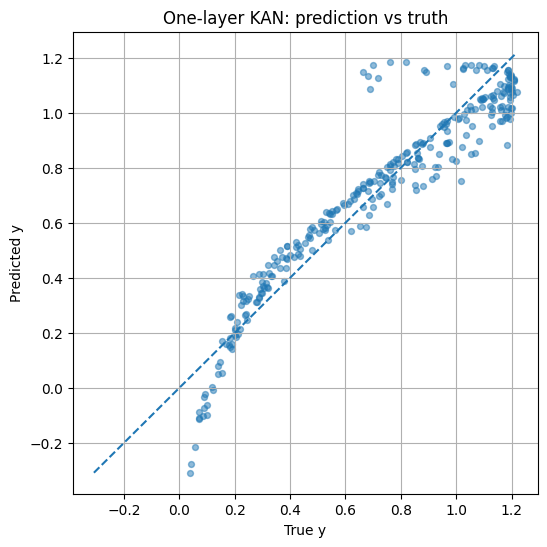

In [106]:
plot_loss_curves(
    train_losses_shallow,
    test_losses_shallow,
    title="One-layer KAN on interaction task"
)

plot_predictions_vs_truth(
    model_shallow,
    x_test,
    y_test,
    title="One-layer KAN: prediction vs truth"
)

### Shallow KAN on interaction regression: discussion

The predicted-vs-true plot shows that the shallow model captures the general trend, but the fit is not perfect. This is expected, since the target contains the interaction term $x_1x_2$, while a one-layer KAN is naturally better suited to additive structure across input coordinates.

Although the basis functions are strictly positive, the final output is not constrained to be positive, because the model combines them using coefficients that may be either positive or negative.

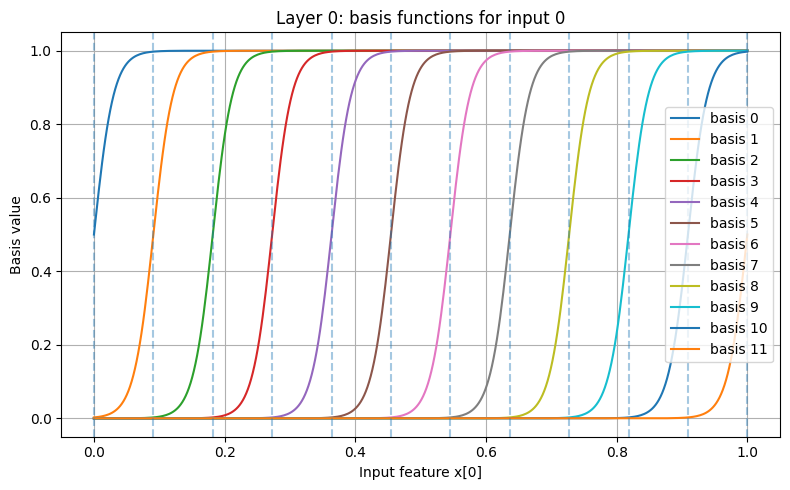

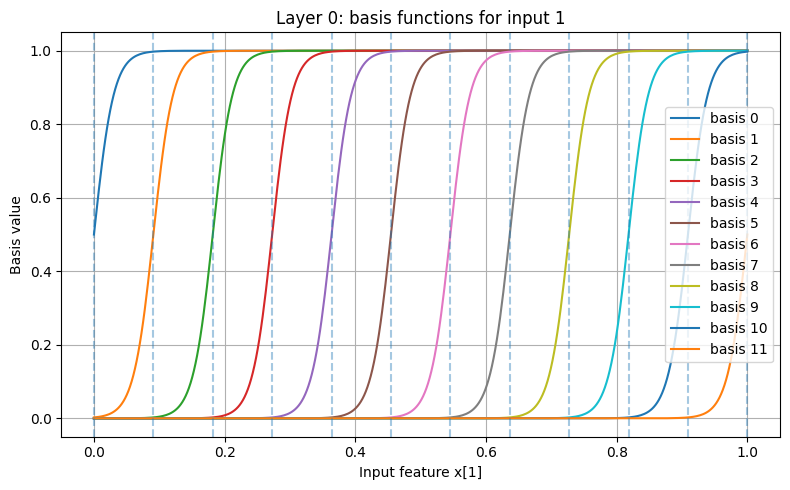

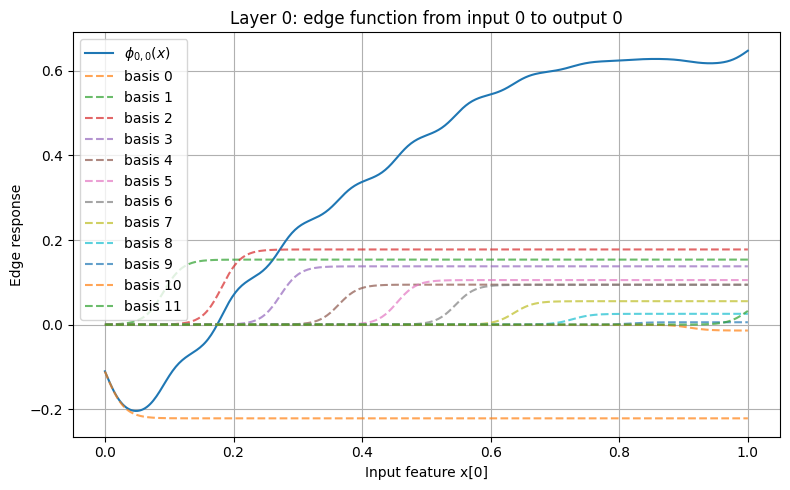

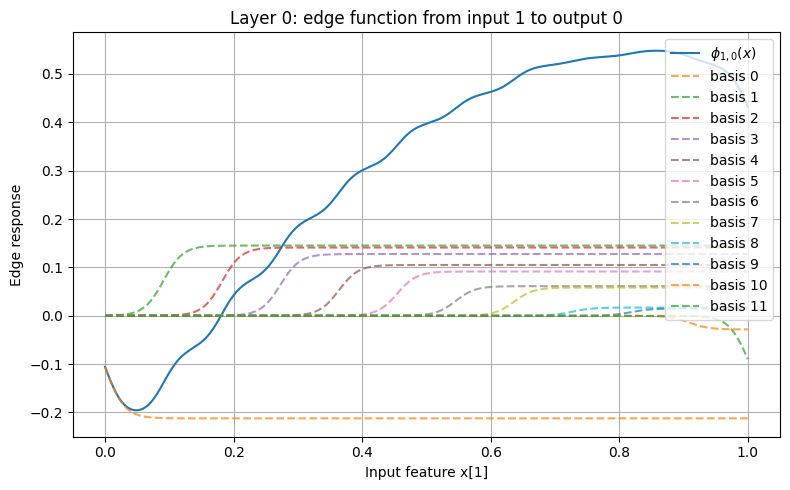

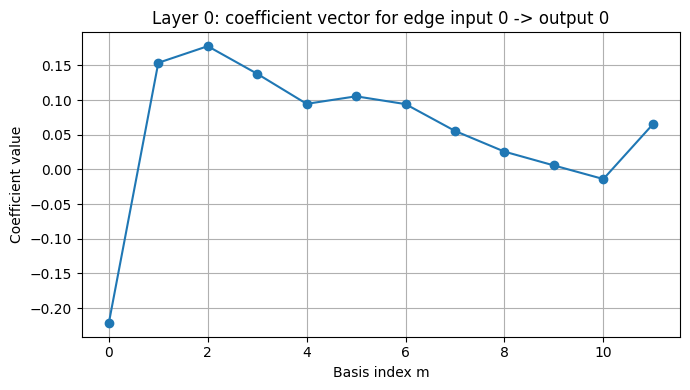

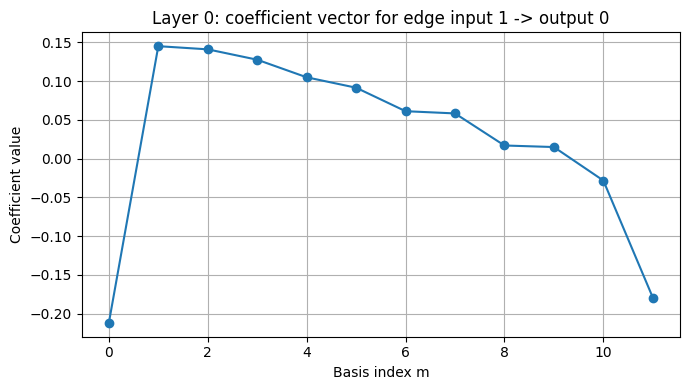

In [107]:
model_shallow.plot_basis_functions(layer_idx=0, in_idx=0, x_range=(0.0, 1.0))
model_shallow.plot_basis_functions(layer_idx=0, in_idx=1, x_range=(0.0, 1.0))

model_shallow.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_shallow.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 1.0), show_basis=True)

model_shallow.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0)
model_shallow.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1)

# One hidden layer

In [140]:
model_hidden = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[8],
    num_basis=12,
    x_min=-3.0,
    x_max=3.0,
    gamma_scale=3.0,
    debug=False,
)

train_losses_hidden, test_losses_hidden = train_regression_model(
    model=model_hidden,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    lr=1e-2,
    num_epochs=2500,
    print_every=250,
)

Epoch    0 | train loss = 0.732217 | test loss = 0.231428
Epoch  250 | train loss = 0.001332 | test loss = 0.001246
Epoch  500 | train loss = 0.001106 | test loss = 0.000993
Epoch  750 | train loss = 0.000804 | test loss = 0.000719
Epoch 1000 | train loss = 0.000521 | test loss = 0.000445
Epoch 1250 | train loss = 0.000409 | test loss = 0.000358
Epoch 1500 | train loss = 0.001503 | test loss = 0.001302
Epoch 1750 | train loss = 0.000308 | test loss = 0.000274
Epoch 2000 | train loss = 0.000287 | test loss = 0.000308
Epoch 2250 | train loss = 0.000516 | test loss = 0.000226


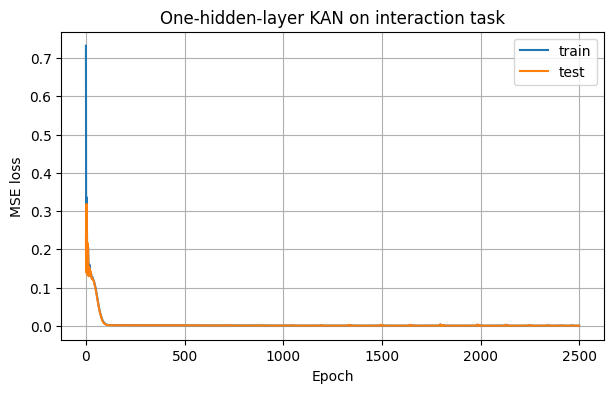

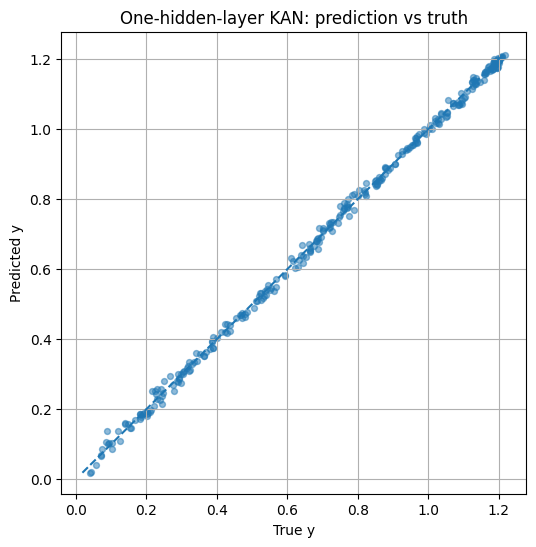

In [141]:
plot_loss_curves(
    train_losses_hidden,
    test_losses_hidden,
    title="One-hidden-layer KAN on interaction task"
)

plot_predictions_vs_truth(
    model_hidden,
    x_test,
    y_test,
    title="One-hidden-layer KAN: prediction vs truth"
)

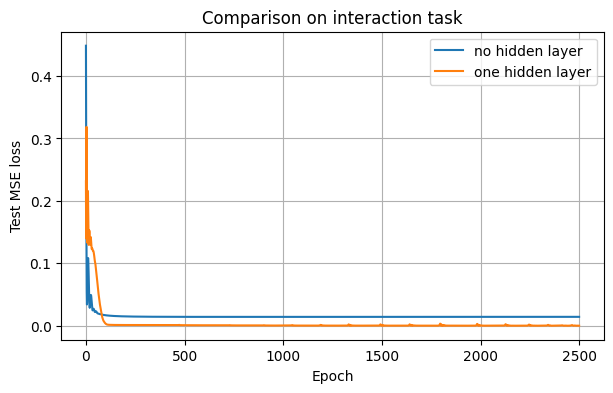

In [142]:
plt.figure(figsize=(7, 4))
plt.plot(test_losses_shallow, label="no hidden layer")
plt.plot(test_losses_hidden, label="one hidden layer")
plt.xlabel("Epoch")
plt.ylabel("Test MSE loss")
plt.title("Comparison on interaction task")
plt.legend()
plt.grid(True)
plt.show()

In [143]:
print(f"Final shallow test loss: {test_losses_shallow[-1]:.6f}")
print(f"Final hidden test loss:  {test_losses_hidden[-1]:.6f}")

Final shallow test loss: 0.014382
Final hidden test loss:  0.000161


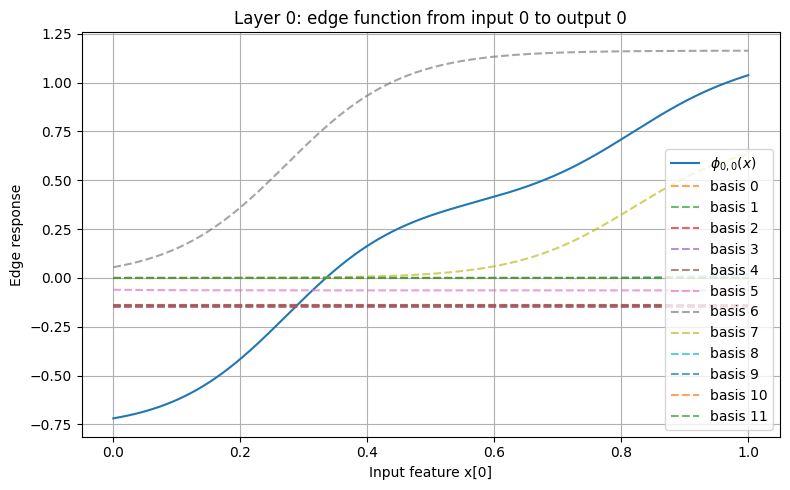

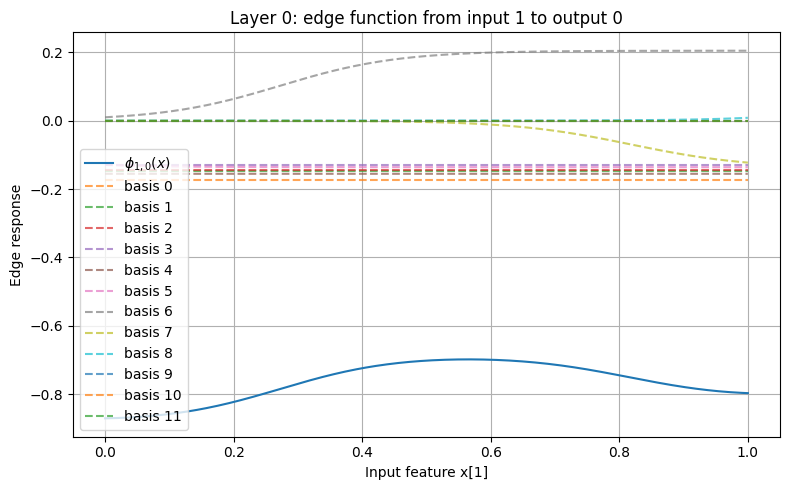

In [144]:
model_hidden.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(0.0, 1.0), show_basis=True)
model_hidden.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(0.0, 1.0), show_basis=True)

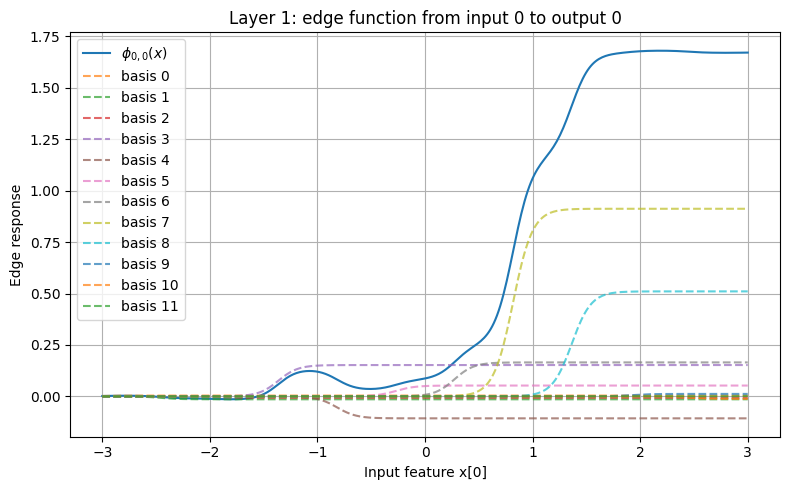

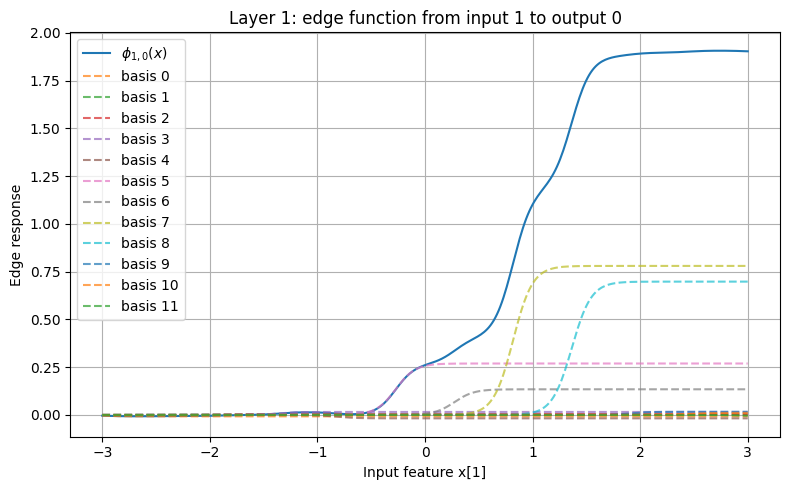

In [145]:
model_hidden.plot_edge_function(layer_idx=1, out_idx=0, in_idx=0, x_range=(-3.0, 3.0), show_basis=True)
model_hidden.plot_edge_function(layer_idx=1, out_idx=0, in_idx=1, x_range=(-3.0, 3.0), show_basis=True)

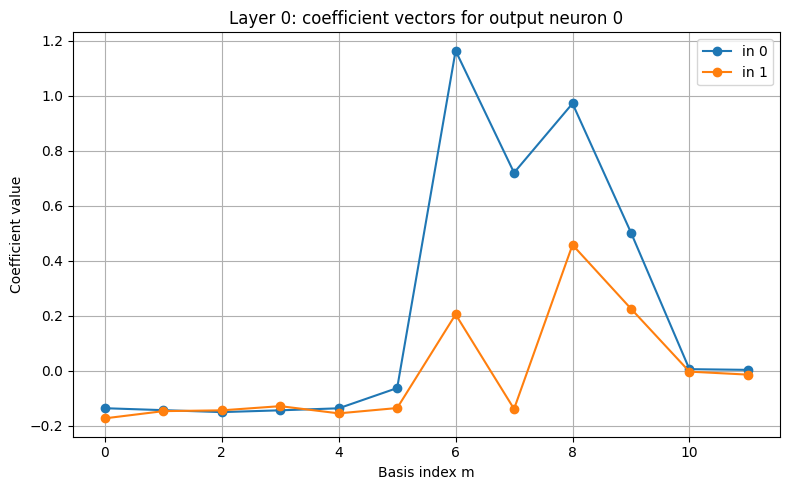

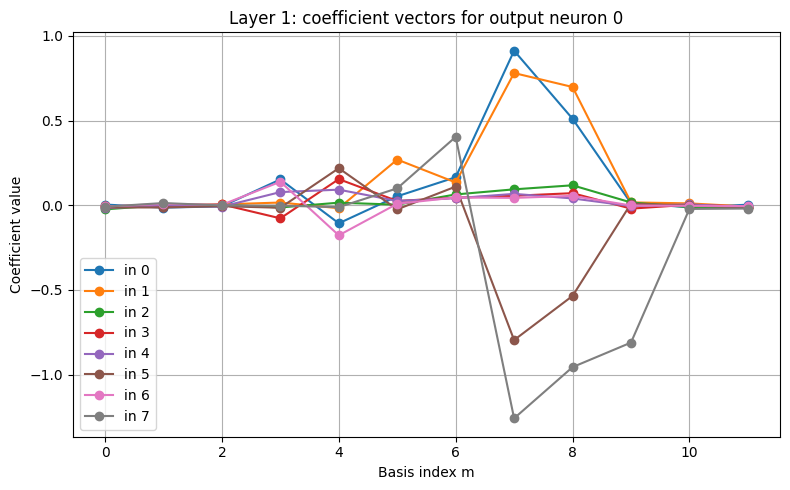

In [146]:
model_hidden.plot_all_coefficient_vectors(layer_idx=0, out_idx=0)
model_hidden.plot_all_coefficient_vectors(layer_idx=1, out_idx=0)

### One-hidden-layer KAN on interaction regression: discussion

Compared to the shallow model, the one-hidden-layer KAN fits the target much more accurately.  
This is expected, since the hidden layer increases the model’s ability to represent interactions between inputs.

Although several basis functions appear almost inactive, this is not necessarily a problem.  
In practice, the network often uses only a subset of the available basis functions strongly, while others make only small corrections or remain near zero because they are not needed in the active input region.

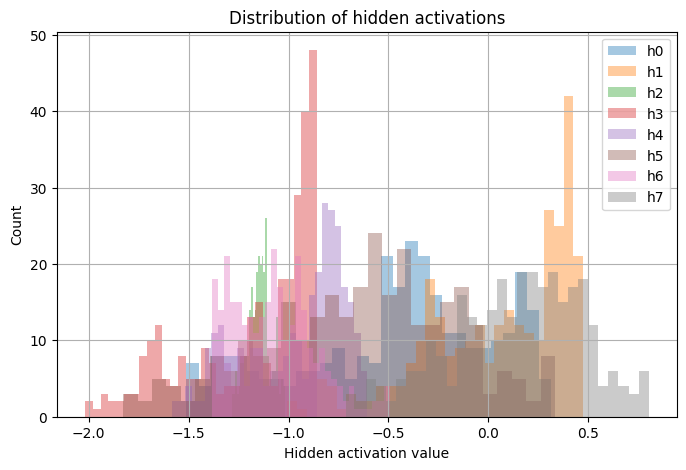

In [147]:
with torch.no_grad():
    layer_outputs = model_hidden.get_layer_outputs(x_test)

hidden_out = layer_outputs[0]  # output of first layer, input to second layer

plt.figure(figsize=(8, 5))
for i in range(hidden_out.shape[1]):
    plt.hist(hidden_out[:, i].numpy(), bins=30, alpha=0.4, label=f"h{i}")
plt.title("Distribution of hidden activations")
plt.xlabel("Hidden activation value")
plt.ylabel("Count")
plt.grid(True)
plt.legend()
plt.show()